<a href="https://colab.research.google.com/github/dsamithmendis/python-programming/blob/main/EES4320_LAB02_LAST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import libraries
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.stats import mode
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 2. Load the Iris dataset
iris = load_iris()
X = iris.data          # Features
y = iris.target        # True labels, used only for evaluation

In [3]:
# 3. Show the dataset as a table
df = pd.DataFrame(X, columns=iris.feature_names)
df["true_target"] = y
df["flower_name"] = df["true_target"].apply(lambda x: iris.target_names[x])
print("First 5 rows of the Iris dataset:")
print(df.head())

First 5 rows of the Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   true_target flower_name  
0            0      setosa  
1            0      setosa  
2            0      setosa  
3            0      setosa  
4            0      setosa  


In [4]:
# 4. Scale the features
# K-Means is distance-based, so scaling is important
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# 5. Create and train the K-Means model
# We use 3 clusters because the Iris dataset has 3 flower species
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [6]:
# 6. Add cluster labels to the dataframe
df["cluster"] = clusters
print("\nFirst 10 rows with cluster labels:")
print(df.head(10))


First 10 rows with cluster labels:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   true_target flower_name  cluster  
0            0      setosa        1  
1            0    

In [7]:
# 7. Map clusters to actual flower labels for evaluation
# K-Means produces cluster numbers, not class names.
# So we match each cluster to the most common true label inside it.
mapped_labels = np.zeros_like(clusters)
for cluster_id in range(3):
    mask = clusters == cluster_id
    mapped_labels[mask] = mode(y[mask], keepdims=True).mode[0]

In [8]:
# 8. Evaluate clustering against true labels
# This is only for checking performance because Iris has known labels.
accuracy = accuracy_score(y, mapped_labels)
print("\nClustering Accuracy after mapping clusters to flower labels:")
print(accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y, mapped_labels))
print("\nClassification Report:")
print(classification_report(y, mapped_labels, target_names=iris.target_names))


Clustering Accuracy after mapping clusters to flower labels:
0.8333333333333334

Confusion Matrix:
[[50  0  0]
 [ 0 39 11]
 [ 0 14 36]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.74      0.78      0.76        50
   virginica       0.77      0.72      0.74        50

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150



In [9]:
# 9. Show cluster centers
centers_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(
    centers_original_scale,
    columns=iris.feature_names
)
print("\nCluster Centers in Original Feature Scale:")
print(centers_df)


Cluster Centers in Original Feature Scale:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           5.801887          2.673585           4.369811          1.413208
1           5.006000          3.428000           1.462000          0.246000
2           6.780851          3.095745           5.510638          1.972340


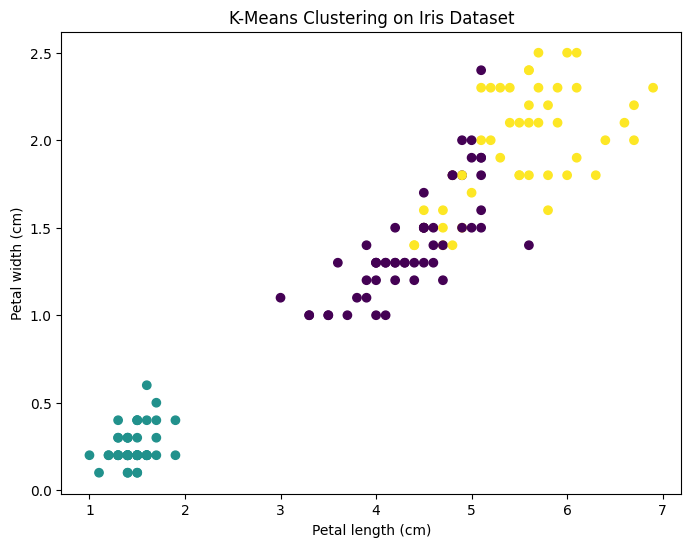

In [10]:
# 10. Visualize clusters using petal length and petal width
plt.figure(figsize=(8, 6))
plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=df["cluster"]
)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("K-Means Clustering on Iris Dataset")
plt.show()